# Denoising Autoencoder — MNIST
This notebook implements a **Denoising Autoencoder** using the MNIST dataset in PyTorch.

**Core concept:**

* Gaussian noise is injected into the input images during training.
* The autoencoder is trained to recover the **original clean images** from their noisy counterparts.
* The performance of three autoencoder architectures is evaluated and compared: **FFNN Autoencoder**, **Transpose-CNN Autoencoder**, and **Upsampled-CNN Autoencoder**.

## 1. Importing Required Packages

In [24]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms

torch_ver = torch.__version__
cuda_ok   = torch.cuda.is_available()
print(f'PyTorch version: {torch_ver}')
print(f'CUDA available: {cuda_ok}')

PyTorch version: 2.11.0+cu128
CUDA available: True


## 2. Defining Transforms

In [25]:
img_transform = transforms.Compose([
    transforms.ToTensor()
])

transform = img_transform

## 3. Downloading MNIST Data

In [26]:
ROOT = 'data'

train_data = datasets.MNIST(root=ROOT, train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root=ROOT, train=False, download=True, transform=transform)

n_train, n_test = len(train_data), len(test_data)
print(f'Training samples : {n_train}')
print(f'Test samples     : {n_test}')

Training samples : 60000
Test samples     : 10000


## 4. Defining DataLoaders

In [27]:
# Hyper-parameters ──────────────────────────────────────────────────────────
valid_size  = 0.2
batch_size  = 20
num_workers = 0

#  Build train / validation split ────────────────────────────────────────────
n_total  = len(train_data)
all_idx  = np.arange(n_total)
np.random.shuffle(all_idx)

cut       = int(np.floor(valid_size * n_total))
valid_idx = all_idx[:cut]
train_idx = all_idx[cut:]

# ── Samplers ──────────────────────────────────────────────────────────────────
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# ── Loaders ───────────────────────────────────────────────────────────────────
loader_cfg = dict(batch_size=batch_size, num_workers=num_workers)

train_loader = DataLoader(train_data, sampler=train_sampler, **loader_cfg)
valid_loader = DataLoader(train_data, sampler=valid_sampler, **loader_cfg)
test_loader  = DataLoader(test_data,  **loader_cfg)

print(f'Train batches: {len(train_loader)}  |  Valid batches: {len(valid_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 2400  |  Valid batches: 600  |  Test batches: 500


## 5. Noise Addition Helper

Gaussian noise is added to the input images to create noisy samples, and pixel values are clipped to the range **[0, 1]** to maintain valid image intensities. The **`noise_factor`** parameter controls the amount of noise introduced, with higher values producing more heavily corrupted images. The autoencoder is trained to reconstruct the original clean images from these noisy inputs, enabling it to learn effective denoising representations.

In [28]:
def add_noise(imgs, noise_factor=0.4):

    perturbation  = torch.randn_like(imgs).mul_(noise_factor)
    corrupted     = imgs + perturbation
    return corrupted.clamp_(0.0, 1.0)

## 6. Visualizing Clean vs Noisy Images

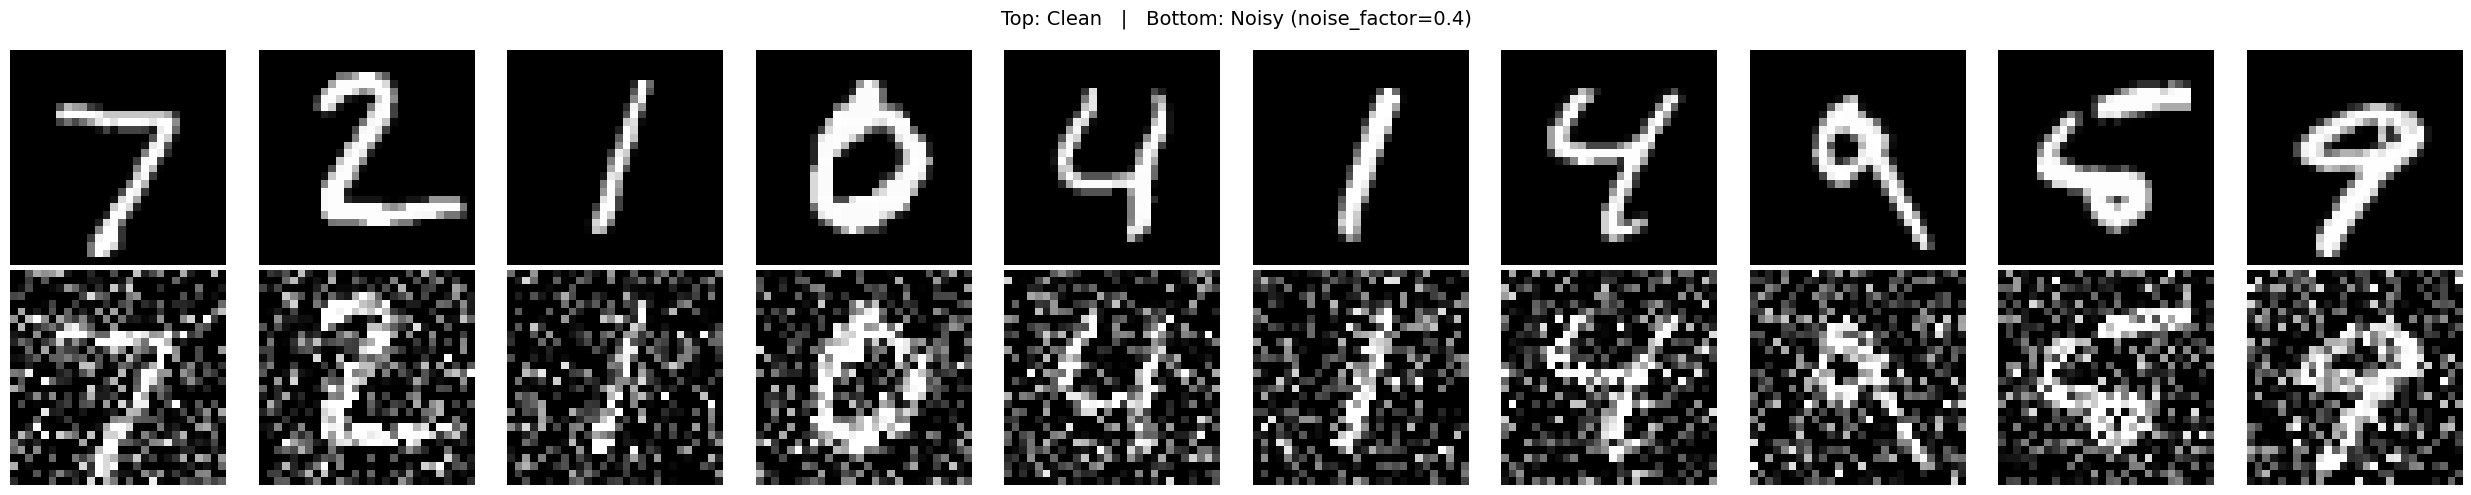

In [29]:
_iter          = iter(test_loader)
sample_images, _ = next(_iter)
noisy_sample   = add_noise(sample_images, noise_factor=0.4)

NUM_SHOW = 10
fig, axes = plt.subplots(2, NUM_SHOW, figsize=(25, 5))
fig.suptitle('Top: Clean   |   Bottom: Noisy (noise_factor=0.4)', fontsize=14)

for col in range(NUM_SHOW):
    for row, batch in enumerate([sample_images, noisy_sample]):
        axes[row, col].imshow(batch[col].squeeze().numpy(), cmap='gray')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 7. Model Architectures

Three autoencoder architectures are defined:

1. **FFNN Autoencoder** – a basic autoencoder that uses fully connected (dense) layers in both the encoder and decoder to learn a compact representation of the input images.
2. **Transpose-CNN Autoencoder** – combines a convolutional encoder for extracting spatial features with a transposed convolution decoder to reconstruct the original images from the learned representations.
3. **Upsampled-CNN Autoencoder** – uses a convolutional encoder and a decoder based on nearest-neighbor upsampling followed by convolutional layers, helping to generate smoother reconstructions and reduce checkerboard artifacts.

In [30]:

# Model 1 — Fully-Connected (FFNN) Autoencoder
class F_Auto_MNIST(nn.Module):

    def __init__(self, en_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, en_dim),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Linear(en_dim, 784),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


# Model 2 — Transpose-CNN Autoencoder
class Tran_conv_Auto_MNIST(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


# Model 3 — Upsampled-CNN Autoencoder
class upsamp_conv_Auto_MNIST(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.de_conv1 = nn.Conv2d(4,  16, kernel_size=3, padding=1)
        self.de_conv2 = nn.Conv2d(16,  1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        z = F.interpolate(z, scale_factor=2, mode='nearest')
        z = F.relu(self.de_conv1(z), inplace=True)
        z = F.interpolate(z, scale_factor=2, mode='nearest')
        return torch.sigmoid(self.de_conv2(z))

## 8. Initialise Models

In [31]:
model_1 = F_Auto_MNIST(en_dim=32)
model_2 = Tran_conv_Auto_MNIST()
model_3 = upsamp_conv_Auto_MNIST()

def weight_init_normal(module):
    if isinstance(module, nn.Linear):
        fan_in = module.in_features
        std    = 1.0 / np.sqrt(fan_in)
        nn.init.normal_(module.weight, mean=0.0, std=std)
        nn.init.zeros_(module.bias)

model_1.apply(weight_init_normal)

use_cuda = True
device   = torch.device('cuda' if (use_cuda and torch.cuda.is_available()) else 'cpu')

for m in (model_1, model_2, model_3):
    m.to(device)

print(model_1, '\n')
print(model_2, '\n')
print(model_3, '\n')
print('Running on:', device)

F_Auto_MNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=784, bias=True)
    (1): Sigmoid()
  )
) 

Tran_conv_Auto_MNIST(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
) 

upsamp_conv_Auto_MNIST(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1,

## 9. Loss Function
**MSELoss (Mean Squared Error Loss)** is used because image reconstruction is a regression task. It measures the difference between the reconstructed and original pixel values, helping the autoencoder produce outputs that closely resemble the clean images.

In [32]:
# Pixel-level regression loss
criterion = nn.MSELoss()

## 10. Training & Validation

**Denoising key change:**


* Input to the model → **noisy** image generated by adding Gaussian noise.
* Target (used for loss computation) → **clean** original image, allowing the model to learn how to remove noise and recover the underlying image.

In [33]:
def trainNet(model, lr, state='fully', noise_factor=0.4, epochs=20):

    optimizer       = optim.Adam(model.parameters(), lr=lr)
    loss_keeper     = {'train': [], 'valid': []}
    valid_loss_min  = np.inf
    ckpt_name       = type(model).__name__ + '_denoising.pth'

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_train = 0.0

        for imgs, _ in train_loader:
            imgs        = imgs.to(device)
            noisy_imgs  = add_noise(imgs, noise_factor).to(device)

            if state == 'fully':
                imgs       = imgs.view(imgs.size(0), -1)
                noisy_imgs = noisy_imgs.view(noisy_imgs.size(0), -1)

            optimizer.zero_grad()
            preds = model(noisy_imgs)
            loss  = criterion(preds, imgs)
            loss.backward()
            optimizer.step()
            running_train += loss.item()

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        running_valid = 0.0

        with torch.no_grad():
            for imgs, _ in valid_loader:
                imgs       = imgs.to(device)
                noisy_imgs = add_noise(imgs, noise_factor).to(device)

                if state == 'fully':
                    imgs       = imgs.view(imgs.size(0), -1)
                    noisy_imgs = noisy_imgs.view(noisy_imgs.size(0), -1)

                preds = model(noisy_imgs)
                running_valid += criterion(preds, imgs).item()

        # ── Epoch summary ─────────────────────────────────────────────────────
        avg_train = running_train / len(train_loader)
        avg_valid = running_valid / len(valid_loader)
        loss_keeper['train'].append(avg_train)
        loss_keeper['valid'].append(avg_valid)

        print(f'Epoch {epoch}/{epochs}  |  Train Loss: {avg_train:.6f}  |  Valid Loss: {avg_valid:.6f}')

        if avg_valid <= valid_loss_min:
            print(f'  ✔ Validation loss improved ({valid_loss_min:.6f} → {avg_valid:.6f}). Saving model...')
            torch.save(model.state_dict(), ckpt_name)
            valid_loss_min = avg_valid

    return loss_keeper

### Train Model 1 — FFNN Autoencoder

In [34]:
m1_loss = trainNet(model_1, lr=0.001, state='fully', noise_factor=0.4)

Epoch 1/20  |  Train Loss: 0.048554  |  Valid Loss: 0.033868
  ✔ Validation loss improved (inf → 0.033868). Saving model...
Epoch 2/20  |  Train Loss: 0.032109  |  Valid Loss: 0.030889
  ✔ Validation loss improved (0.033868 → 0.030889). Saving model...
Epoch 3/20  |  Train Loss: 0.030662  |  Valid Loss: 0.030245
  ✔ Validation loss improved (0.030889 → 0.030245). Saving model...
Epoch 4/20  |  Train Loss: 0.030245  |  Valid Loss: 0.029967
  ✔ Validation loss improved (0.030245 → 0.029967). Saving model...
Epoch 5/20  |  Train Loss: 0.030002  |  Valid Loss: 0.029654
  ✔ Validation loss improved (0.029967 → 0.029654). Saving model...
Epoch 6/20  |  Train Loss: 0.029778  |  Valid Loss: 0.029572
  ✔ Validation loss improved (0.029654 → 0.029572). Saving model...
Epoch 7/20  |  Train Loss: 0.029623  |  Valid Loss: 0.029468
  ✔ Validation loss improved (0.029572 → 0.029468). Saving model...
Epoch 8/20  |  Train Loss: 0.029469  |  Valid Loss: 0.029201
  ✔ Validation loss improved (0.029468 → 

### Train Model 2 — Transpose-CNN Autoencoder

In [35]:
m2_loss = trainNet(model_2, lr=0.001, state='conv', noise_factor=0.4)

Epoch 1/20  |  Train Loss: 0.040152  |  Valid Loss: 0.022657
  ✔ Validation loss improved (inf → 0.022657). Saving model...
Epoch 2/20  |  Train Loss: 0.021601  |  Valid Loss: 0.020629
  ✔ Validation loss improved (0.022657 → 0.020629). Saving model...
Epoch 3/20  |  Train Loss: 0.019948  |  Valid Loss: 0.018885
  ✔ Validation loss improved (0.020629 → 0.018885). Saving model...
Epoch 4/20  |  Train Loss: 0.018212  |  Valid Loss: 0.017613
  ✔ Validation loss improved (0.018885 → 0.017613). Saving model...
Epoch 5/20  |  Train Loss: 0.017499  |  Valid Loss: 0.017385
  ✔ Validation loss improved (0.017613 → 0.017385). Saving model...
Epoch 6/20  |  Train Loss: 0.017195  |  Valid Loss: 0.017075
  ✔ Validation loss improved (0.017385 → 0.017075). Saving model...
Epoch 7/20  |  Train Loss: 0.017012  |  Valid Loss: 0.016910
  ✔ Validation loss improved (0.017075 → 0.016910). Saving model...
Epoch 8/20  |  Train Loss: 0.016846  |  Valid Loss: 0.016690
  ✔ Validation loss improved (0.016910 → 

### Train Model 3 — Upsampled-CNN Autoencoder

In [36]:
m3_loss = trainNet(model_3, lr=0.001, state='conv', noise_factor=0.4)

Epoch 1/20  |  Train Loss: 0.025358  |  Valid Loss: 0.015714
  ✔ Validation loss improved (inf → 0.015714). Saving model...
Epoch 2/20  |  Train Loss: 0.014668  |  Valid Loss: 0.013990
  ✔ Validation loss improved (0.015714 → 0.013990). Saving model...
Epoch 3/20  |  Train Loss: 0.013681  |  Valid Loss: 0.013384
  ✔ Validation loss improved (0.013990 → 0.013384). Saving model...
Epoch 4/20  |  Train Loss: 0.013271  |  Valid Loss: 0.013054
  ✔ Validation loss improved (0.013384 → 0.013054). Saving model...
Epoch 5/20  |  Train Loss: 0.012992  |  Valid Loss: 0.012769
  ✔ Validation loss improved (0.013054 → 0.012769). Saving model...
Epoch 6/20  |  Train Loss: 0.012760  |  Valid Loss: 0.012598
  ✔ Validation loss improved (0.012769 → 0.012598). Saving model...
Epoch 7/20  |  Train Loss: 0.012582  |  Valid Loss: 0.012464
  ✔ Validation loss improved (0.012598 → 0.012464). Saving model...
Epoch 8/20  |  Train Loss: 0.012456  |  Valid Loss: 0.012288
  ✔ Validation loss improved (0.012464 → 

## 11. Load Best Saved Weights

In [37]:
checkpoints = {
    model_1: 'F_Auto_MNIST_denoising.pth',
    model_2: 'Tran_conv_Auto_MNIST_denoising.pth',
    model_3: 'upsamp_conv_Auto_MNIST_denoising.pth',
}

for mdl, ckpt in checkpoints.items():
    state_dict = torch.load(ckpt, map_location=device)
    mdl.load_state_dict(state_dict)

print('Best weights loaded for all models.')

Best weights loaded for all models.


## 12. Plotting Training & Validation Loss

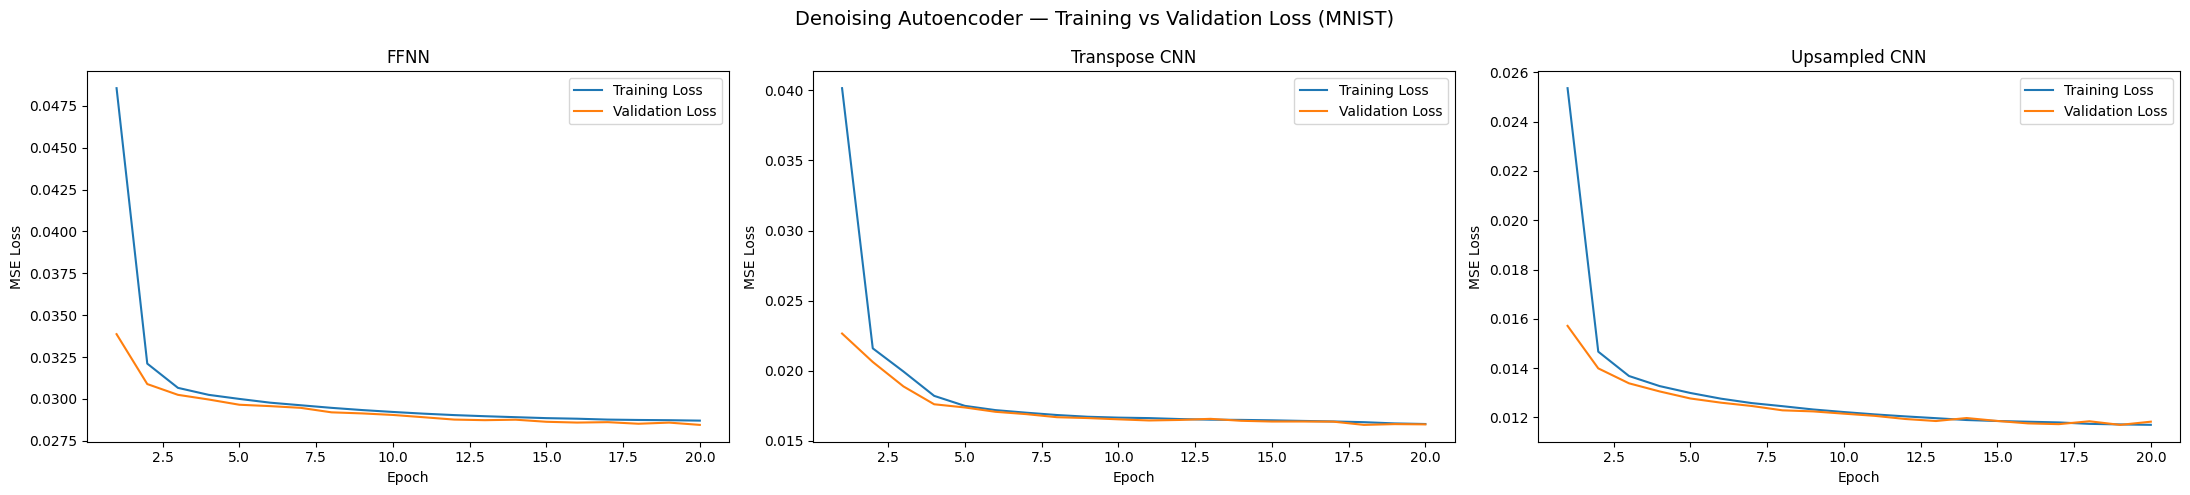

In [38]:
arch_names  = ['FFNN', 'Transpose CNN', 'Upsampled CNN']
all_losses  = [m1_loss, m2_loss, m3_loss]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Denoising Autoencoder — Training vs Validation Loss (MNIST)', fontsize=14)

for ax, losses, name in zip(axes, all_losses, arch_names):
    epochs_range = range(1, len(losses['train']) + 1)
    ax.plot(epochs_range, losses['train'], label='Training Loss')
    ax.plot(epochs_range, losses['valid'], label='Validation Loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 13. Testing — Denoising Visualisation
Three rows are shown per model:


1. **Clean** – the original image from the dataset.
2. **Noisy** – the corrupted image created by adding Gaussian noise and used as the model input.
3. **Reconstructed** – the denoised image produced by the autoencoder after attempting to recover the original image.

In [39]:
def test_denoising(model, state='fully', noise_factor=0.4):

    model.eval()

    imgs, _ = next(iter(test_loader))
    imgs    = imgs.to(device)
    noisy   = add_noise(imgs, noise_factor).to(device)

    with torch.no_grad():
        if state == 'fully':
            flat_noisy = noisy.view(noisy.size(0), -1)
            flat_out   = model(flat_noisy)
            recon      = flat_out.view(batch_size, 1, 28, 28)
        else:
            recon = model(noisy)

    clean_np = imgs.cpu().numpy()
    noisy_np = noisy.cpu().numpy()
    recon_np = recon.cpu().numpy()

    model_name = type(model).__name__
    fig, axes  = plt.subplots(3, 10, figsize=(25, 7))
    fig.suptitle(
        f'{model_name}  |  Row 1: Clean   Row 2: Noisy   Row 3: Reconstructed',
        fontsize=12
    )

    row_data = [clean_np, noisy_np, recon_np]
    for row_idx, data in enumerate(row_data):
        for col_idx in range(10):
            axes[row_idx, col_idx].imshow(data[col_idx].squeeze(), cmap='gray')
            axes[row_idx, col_idx].axis('off')

    plt.tight_layout()
    plt.show()

### FFNN Denoising Results

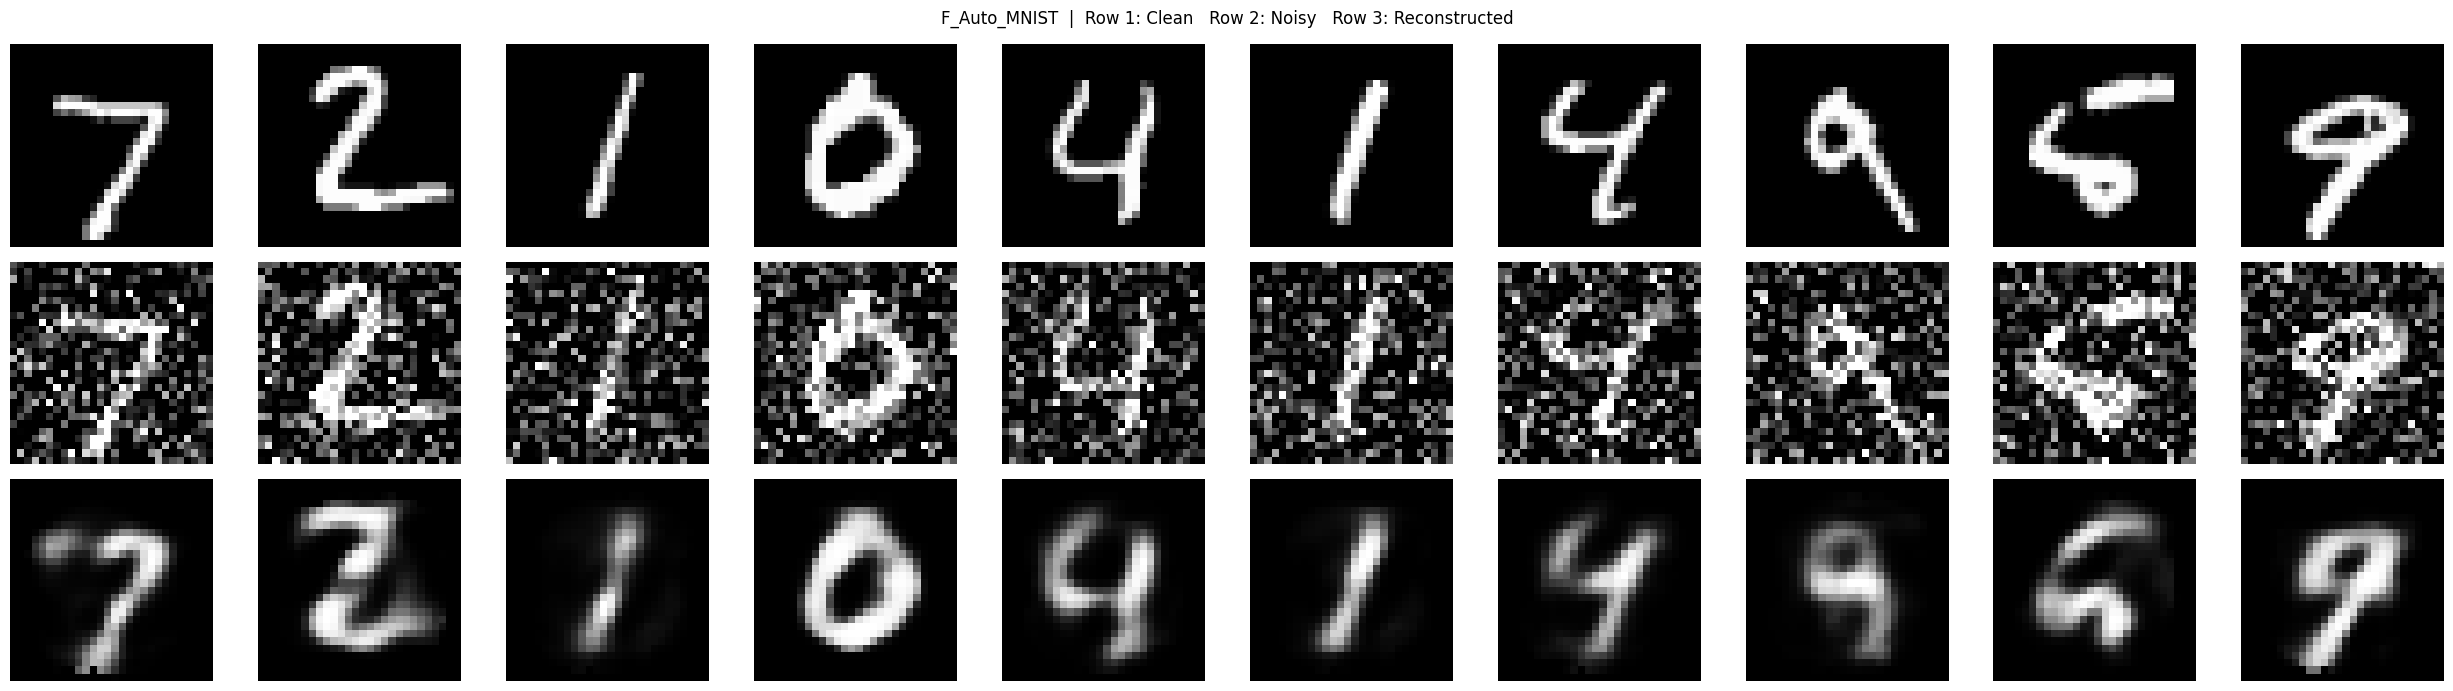

In [40]:
test_denoising(model_1, state='fully', noise_factor=0.4)

### Transpose-CNN Denoising Results

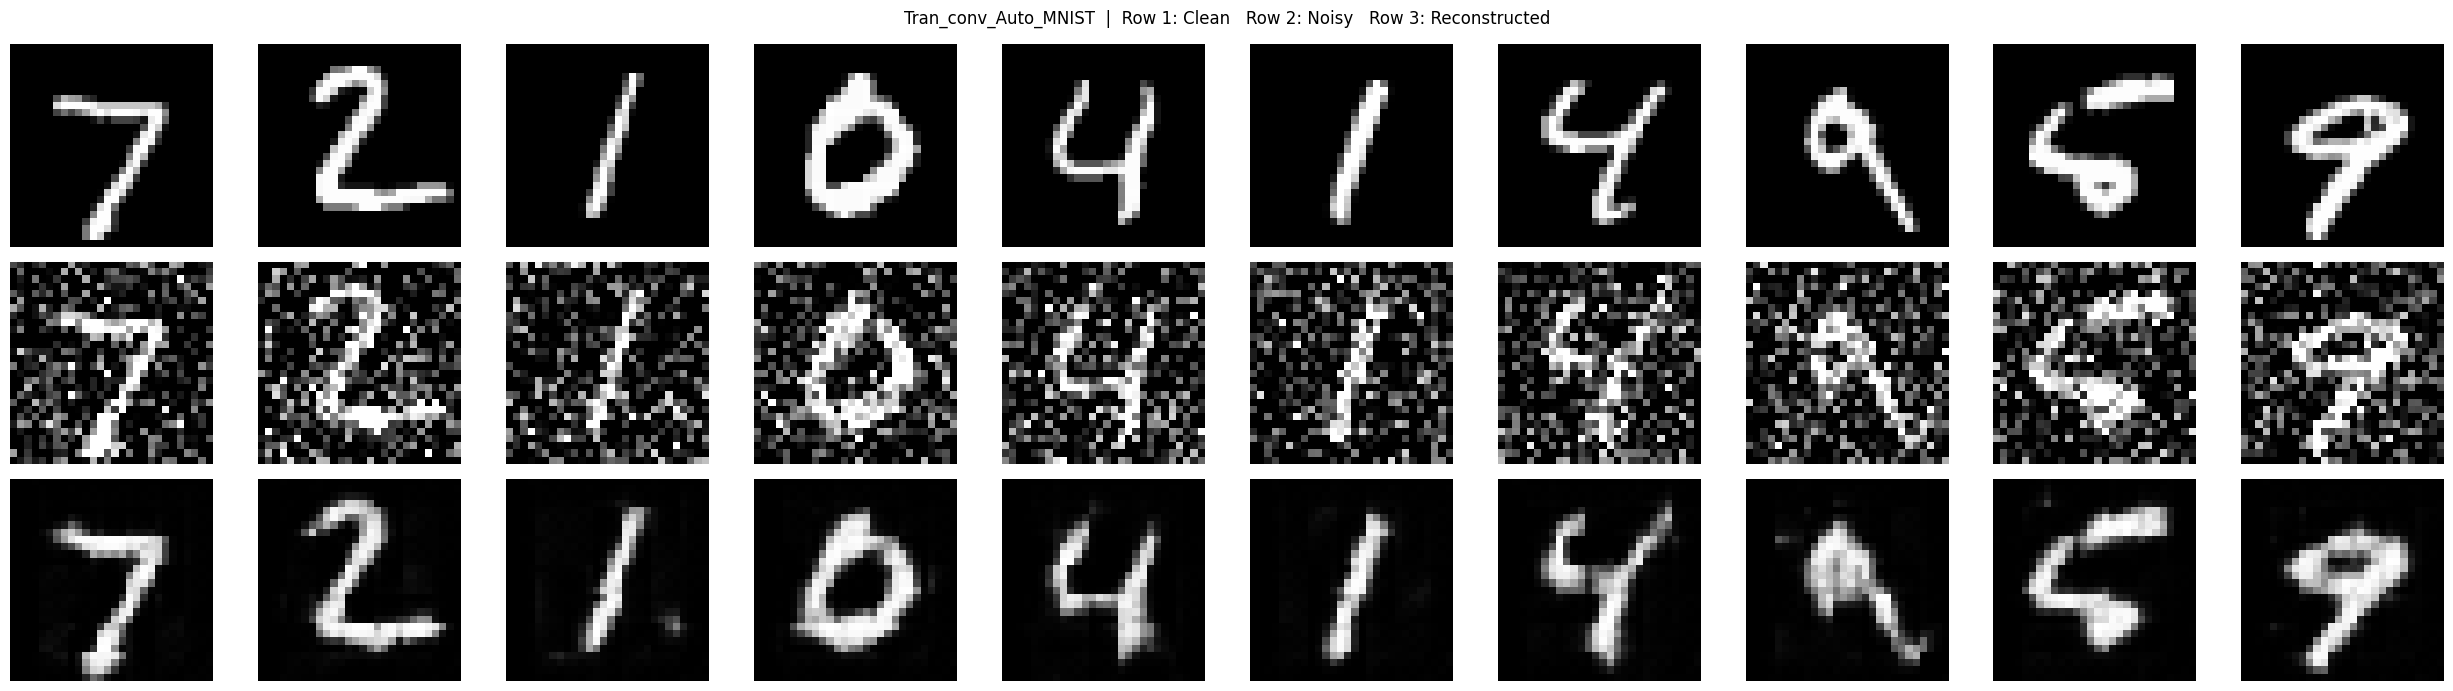

In [41]:
test_denoising(model_2, state='conv', noise_factor=0.4)

### Upsampled-CNN Denoising Results

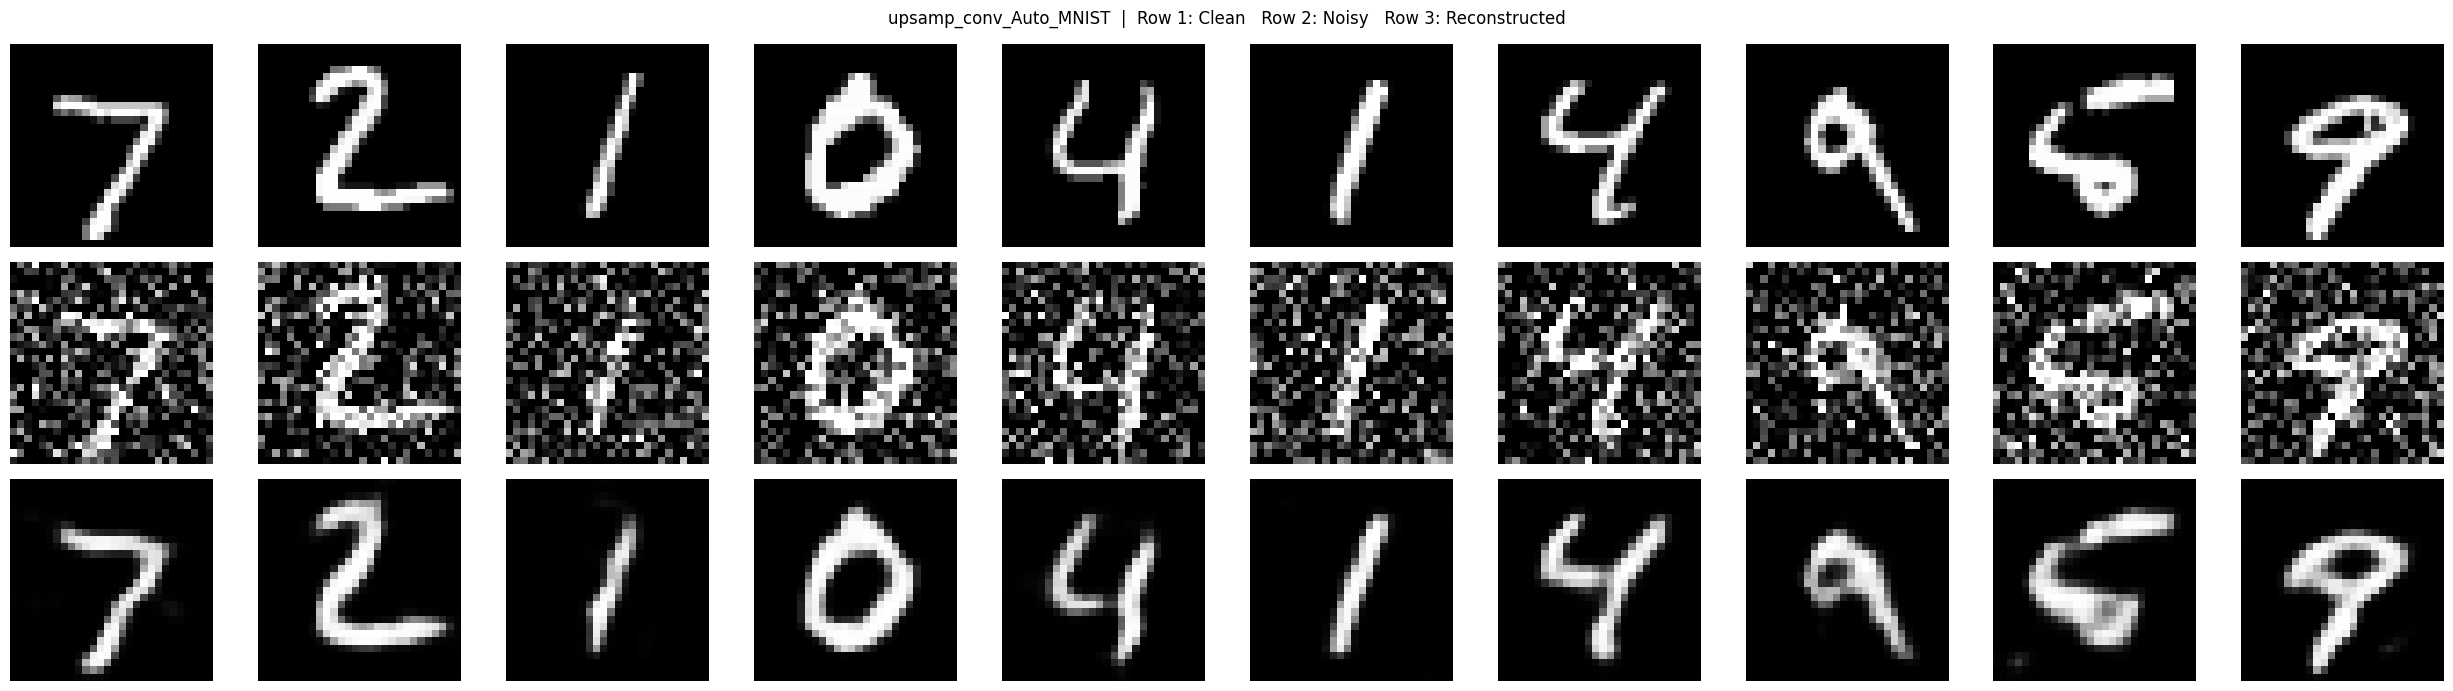

In [42]:
test_denoising(model_3, state='conv', noise_factor=0.4)

## 14. Noise Factor Sensitivity Analysis
We evaluate **Model 3 (Upsampled-CNN Autoencoder)** across multiple noise levels to assess its robustness and generalization ability. This helps determine how effectively the model can reconstruct clean images when the input is affected by varying amounts of noise.

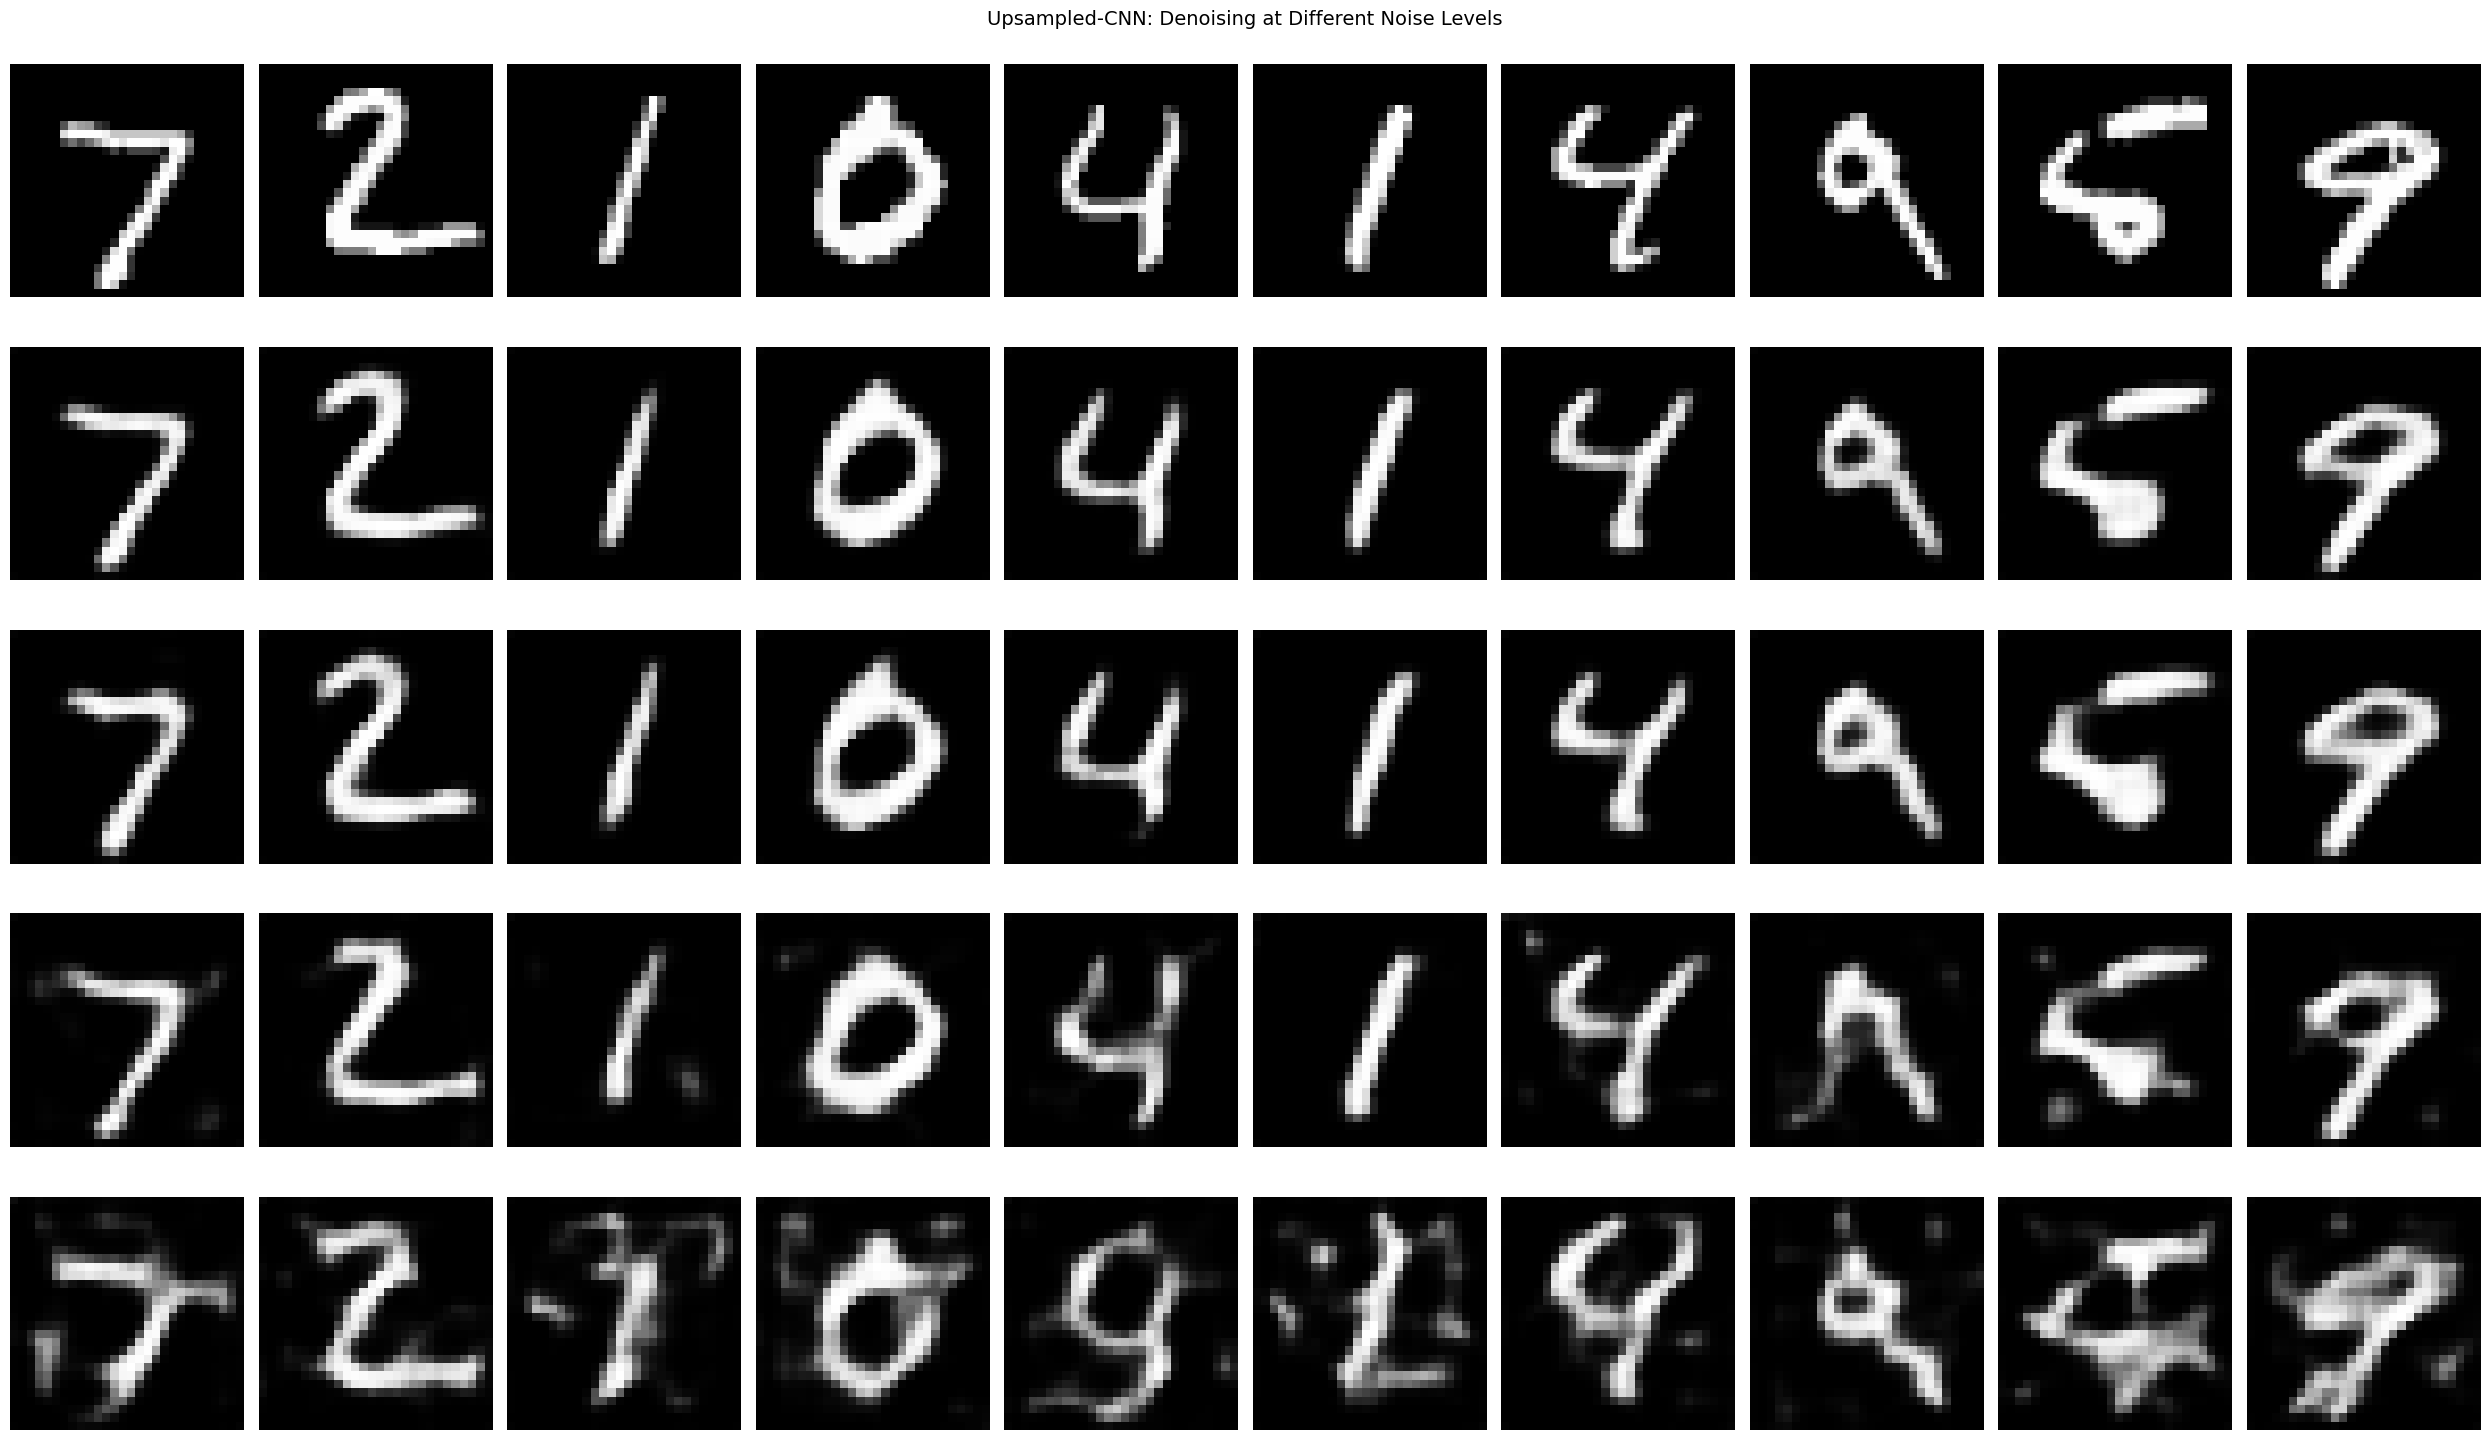

In [43]:
NOISE_LEVELS = [0.1, 0.3, 0.5, 0.7]
N_COLS       = 10

model_3.eval()
test_imgs, _ = next(iter(test_loader))
test_imgs    = test_imgs.to(device)

n_rows = len(NOISE_LEVELS) + 1   # +1 for the clean reference row
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(25, 3 * n_rows))
fig.suptitle('Upsampled-CNN: Denoising at Different Noise Levels', fontsize=14)

for col in range(N_COLS):
    axes[0, col].imshow(test_imgs[col].cpu().squeeze().numpy(), cmap='gray')
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('Clean', rotation=0, labelpad=40, fontsize=9)

for row_offset, nf in enumerate(NOISE_LEVELS, start=1):
    noisy_batch = add_noise(test_imgs, nf).to(device)
    with torch.no_grad():
        recon_batch = model_3(noisy_batch).cpu().numpy()

    for col in range(N_COLS):
        axes[row_offset, col].imshow(recon_batch[col].squeeze(), cmap='gray')
        axes[row_offset, col].axis('off')
    axes[row_offset, 0].set_ylabel(f'nf={nf}', rotation=0, labelpad=40, fontsize=9)

plt.tight_layout()
plt.show()

## Summary
| Model   | Architecture | Decoder Style            | Checkerboard Artifacts |
| ------- | ------------ | ------------------------ | ---------------------- |
| Model 1 | FFNN         | Fully Connected Layers   | N/A                    |
| Model 2 | CNN          | Transposed Convolution   | May Occur              |
| Model 3 | CNN          | Upsampling + Convolution | Largely Reduced        |

**Key observations:**

* CNN-based autoencoders achieve better denoising performance than FFNN models by effectively capturing spatial features in images.
* The **Upsampled-CNN (Model 3)** generally produces higher-quality reconstructions with fewer visual artifacts.
* As the **noise_factor** increases, the denoising task becomes more challenging, leading to slightly blurrier outputs while still preserving the main image structure.
* **MSELoss** is well-suited for this task because it directly measures pixel-level reconstruction error between the output and the original image.